# 🏷️ Fashion Insta — Cadrage Projet IA
## Architecture Hexagonale — Domain / Ports / Adapters

---

> **Projet** : Application mobile de recommandation vestimentaire basée sur des photos  
> **Partenaire stratégique** : Microsoft Azure  
> **Auteur** : Rafael CEREZO MARTIN — Avril 2026

### 🏗️ Principe d'architecture hexagonale appliqué

```
┌─────────────────────────────────────────────────────────────────┐
│  ADAPTERS (sources de données interchangeables)                 │
│  ┌─────────────────┐   ┌──────────────────┐   ┌──────────────┐  │
│  │ ConstantsAdapter│   │  CSVAdapter      │   │  IHMAdapter  │  │
│  │ (utilisé ici)   │   │  (futur)         │   │  (futur)     │  │
│  └────────┬────────┘   └────────┬─────────┘   └──────┬───────┘  │
│           │                    │                     │          │
│           └────────────────────┼─────────────────────┘          │
│  PORTS (interfaces)            ▼                                │
│  ┌──────────────────────────────────────────────────────────┐   │
│  │  DataRepositoryPort: load_profils() / load_phases() ...  │   │
│  └─────────────────────────────┬────────────────────────────┘   │
│                                ▼                                │
│  DOMAIN (logique métier pure)                                   │
│  ┌──────────────────────────────────────────────────────────┐   │
│  │  CadrageService: compute_cout_phase() / compute_roi() .. │   │
│  └─────────────────────────────┬────────────────────────────┘   │
│                                ▼                                │
│  PORTS (sortie)                                                 │
│  ┌──────────────────────────────────────────────────────────┐   │
│  │  ReportPort: render_tables() / render_charts() ...       │   │
│  └─────────────────────────────┬────────────────────────────┘   │
│                                ▼                                │
│  ADAPTERS (sortie)                                              │
│  ┌─────────────────┐   ┌──────────────────┐                     │
│  │ NotebookRenderer│   │  PPTXExporter    │                     │
│  │ (utilisé ici)   │   │  (futur)         │                     │
│  └─────────────────┘   └──────────────────┘                     │
└─────────────────────────────────────────────────────────────────┘
```

**Étape actuelle** : données depuis constantes (`ConstantsAdapter`) → affichage notebook (`NotebookRenderer`)  
**Prochaine étape** : brancher `CSVAdapter` ou `IHMAdapter` sans toucher au domaine

---
## 📦 Cellule 1 — Setup : imports & palette

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Palette Fashion Insta ─────────────────────────────────────────────────────
GOLD       = '#7D6608'
GOLD_DARK  = '#5C4D06'
BLUE       = '#4A90D9'
GREEN      = '#2E8B57'
PURPLE     = '#7B68EE'
ORANGE     = '#CD853F'
RED_MUTED  = '#C0392B'
DARK_TEXT  = '#1A1A1A'
BG_LIGHT   = '#FAFAF8'
PHASE_COLORS = ['#4A90D9', GOLD, '#2E8B57', '#7B68EE']

plt.rcParams.update({
    'figure.facecolor': BG_LIGHT, 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

HORAS_SEMANA      = 40
JOURS_PAR_SEMAINE = 5

print('✅ Setup OK — Fashion Insta Cadrage IA (Architecture Hexagonale)')

✅ Setup OK — Fashion Insta Cadrage IA (Architecture Hexagonale)


---
## 🔷 COUCHE DOMAINE — Modèles de données (dataclasses)

> Définit **ce que sont** les entités métier, indépendamment de toute source ou affichage.

In [4]:
from dataclasses import dataclass, field
from typing import List, Dict, Optional

# ─────────────────────────────────────────────────────────────────────────────
# DOMAINE : Entités métier
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Profil:
    """Profil Data interne Fashion Insta."""
    nom: str
    initiales: str
    effectif: int
    tjm_eur: float          # TJM individuel €/jour
    categorie: str          # Technique | Métier | Conformité
    description: str

    @property
    def tjm_equipe(self) -> float:
        """Coût journalier total du groupe (TJM × effectif)."""
        return self.tjm_eur * self.effectif


@dataclass
class Phase:
    """Phase du projet avec durée et livrable clé."""
    id: str                 # 'P1' … 'P4'
    nom: str
    semaines: int           # 0 = ongoing (maintenance)
    debut: str
    fin: str
    livrable_cle: str

    @property
    def jours_ouvres(self) -> int:
        return self.semaines * JOURS_PAR_SEMAINE


@dataclass
class Implication:
    """Taux d'implication (0.0–1.0) d'un profil pour chaque phase."""
    profil_nom: str
    taux_par_phase: Dict[str, float]   # {'P1': 0.5, 'P2': 1.0, ...}


@dataclass
class Brique:
    """Brique technique de la solution IA end-to-end."""
    id: str 
    nom: str
    service_azure: str
    fonction_cle: str
    categorie_cout: str     # Compute | Storage | IA/API | Sécurité | Hors périmètre
    complexite: Optional[int]  # 1–5
    chiffrable: bool = True


@dataclass
class ServiceRecurrent:
    """Coût récurrent mensuel d'un service Azure en production."""
    nom: str
    categorie: str
    cout_best_eur: float
    cout_worst_eur: float
    justification: str

    @property
    def cout_moyen(self) -> float:
        return (self.cout_best_eur + self.cout_worst_eur) / 2


@dataclass
class GainMarketing:
    """Gain annuel estimé par le marketing."""
    canal: str
    ca_base_eur: float
    taux_croissance: float   # 0.14 = +14%

    @property
    def gain_annuel(self) -> float:
        return self.ca_base_eur * self.taux_croissance


print('✅ Entités domaine définies : Profil, Phase, Implication, Brique, ServiceRecurrent, GainMarketing')

✅ Entités domaine définies : Profil, Phase, Implication, Brique, ServiceRecurrent, GainMarketing


---
## 🔷 COUCHE PORTS — Interfaces (contrats)

> Définit **comment** accéder aux données et **comment** publier les résultats, sans implémenter.

In [5]:
from abc import ABC, abstractmethod

# ─────────────────────────────────────────────────────────────────────────────
# PORT D'ENTRÉE : DataRepositoryPort
# ─────────────────────────────────────────────────────────────────────────────

class DataRepositoryPort(ABC):
    """Port d'entrée : tout adaptateur de données DOIT implémenter ces méthodes."""

    @abstractmethod
    def load_profils(self) -> List[Profil]:
        """Charge la liste des profils Data & IA de l'équipe."""
        ...

    @abstractmethod
    def load_phases(self) -> List[Phase]:
        """Charge les phases du projet avec durée et livrables."""
        ...

    @abstractmethod
    def load_implications(self) -> List[Implication]:
        """Charge les taux d'implication (%) par profil × phase."""
        ...

    @abstractmethod
    def load_briques(self) -> List[Brique]:
        """Charge les briques techniques de la solution."""
        ...

    @abstractmethod
    def load_services_recurrents(self) -> List[ServiceRecurrent]:
        """Charge les coûts récurrents mensuels Azure."""
        ...

    @abstractmethod
    def load_gains_marketing(self) -> List[GainMarketing]:
        """Charge les estimations de gains marketing."""
        ...


# ─────────────────────────────────────────────────────────────────────────────
# PORT DE SORTIE : ReportPort
# ─────────────────────────────────────────────────────────────────────────────

class ReportPort(ABC):
    """Port de sortie : tout renderer de rapport DOIT implémenter ces méthodes."""

    @abstractmethod
    def render_profils(self, df: pd.DataFrame) -> None: ...

    @abstractmethod
    def render_cout_phases(self, df: pd.DataFrame) -> None: ...

    @abstractmethod
    def render_roi(self, df: pd.DataFrame, break_even_mois: int) -> None: ...

    @abstractmethod
    def render_raci(self, df: pd.DataFrame) -> None: ...

    @abstractmethod
    def render_recurrents(self, df: pd.DataFrame) -> None: ...


print('✅ Ports définis : DataRepositoryPort (entrée) + ReportPort (sortie)')

✅ Ports définis : DataRepositoryPort (entrée) + ReportPort (sortie)


---
## 🔷 COUCHE ADAPTERS (entrée) — `ConstantsAdapter`

> Implémentation concrète du port d'entrée. **Pour passer au CSV ou à l'IHM, seul cet adapter change.**

### EDITION DES VALEURS 

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# ADAPTER D'ENTRÉE : ConstantsAdapter
# Source de données : constantes hardcodées dans le notebook
# Futur : remplacer par CSVAdapter('data/profils.csv') ou IHMAdapter()
# ─────────────────────────────────────────────────────────────────────────────

class ConstantsAdapter(DataRepositoryPort):
    """
    Adaptateur qui lit les données depuis des constantes Python.
    Implémente DataRepositoryPort.
    À remplacer par CSVAdapter ou IHMAdapter sans modifier le domaine.
    """
    def load_profils(self) -> List[Profil]:
        # TJM issus du document interne Fashion Insta (P11_Profils_Data.pdf)
        return [
            Profil('Tech Lead'                     , 'TL'   , 1, 400, 'Technique'  , 'Valide architecture Azure, revues techniques et choix algorithmes'),
            Profil('Data Engineer'                 , 'DE'   , 2, 370, 'Technique'  , 'Centralisation des données, pipelines, feature engineering'),
            Profil('Data Scientist'                , 'DS'   , 3, 350, 'Technique'  , 'Développement modèles IA, évaluation métriques, fine-tuning'),
            Profil('MLOps Engineer'                , 'MLOPS', 1, 360, 'Technique'  , 'MLflow tracking, déploiement endpoints Azure ML, CI/CD'),
            Profil('Product Owner / Chef de Projet', 'PO'   , 1, 400, 'Métier'     , 'Coordination projet, critères de succès, communication COMEX'),
            Profil('Expert Métier'                 , 'EM'   , 1, 400, 'Métier'     , 'Validation qualité recommandations (point de vue stylistique)'),
            Profil('DPO / Référent RGPD'           , 'DPO'  , 1, 400, 'Conformité' , 'Validation RGPD, gestion données personnelles (photos)'),
        ]
    def load_phases(self) -> List[Phase]:
        return [
            Phase('P1', 'Cadrage & Data',            4,  'S1' , 'S4'     ,  'Pipeline données + validation RGPD'),
            Phase('P2', 'Modélisation IA',           8,  'S4' , 'S12'    , 'Modèles IA entraînés + virtual try-on'),
            Phase('P3', 'MLOps & Déploiement',       6,  'S12', 'S18'    , 'Endpoints Azure ML déployés (prod)'),
            Phase('P4', 'Production & Maintenance',  0,  'M6+', 'ongoing', 'Rapports ROI + retraining trimestriel'),
        ]
    def load_implications(self) -> List[Implication]:
        # Taux d'implication (0.0–1.0) par profil × phase
        # Justification : voir Section 4 du cadrage
        raw = {
            'Tech Lead':                      {'P1': 0.50, 'P2': 0.50, 'P3': 1.00, 'P4': 0.20},  # P3=100% : supervision déploiement prod = phase critique
            'Data Engineer':                  {'P1': 1.00, 'P2': 0.50, 'P3': 0.50, 'P4': 0.50},  # P1=100% : pipeline données = tâche principale de la phase
            'Data Scientist':                 {'P1': 0.20, 'P2': 1.00, 'P3': 0.50, 'P4': 0.50},  # P2=100% : développement modèles = cœur de la phase
            'MLOps Engineer':                 {'P1': 0.20, 'P2': 0.50, 'P3': 1.00, 'P4': 0.50},  # P3=100% : déploiement endpoints Azure ML = rôle central
            'Product Owner / Chef de Projet': {'P1': 0.50, 'P2': 0.10, 'P3': 0.10, 'P4': 0.10},
            'Expert Métier':                  {'P1': 0.10, 'P2': 0.30, 'P3': 1.00, 'P4': 0.20},  # P3=100% : validation qualité finale avant présentation COMEX
            'DPO / Référent RGPD':            {'P1': 0.50, 'P2': 0.10, 'P3': 0.30, 'P4': 0.10},
        }
        return [Implication(nom, taux) for nom, taux in raw.items()]
    def load_briques(self) -> List[Brique]:
        return [
            Brique(1, 'App Mobile', 'iOS/Android — hors périmètre Data'                          , 'Interface utilisateur, capture garde-robe', 'Hors périmètre' , None, chiffrable=False),
            Brique(2, 'Auth & Gateway', 'Azure API Management + Active Directory B2C'            , 'Auth centralisée, routing, rate-limiting (400K users)'       , 'Compute' , 2),
            Brique(3, 'Sécurité & RGPD', 'Azure Key Vault + Microsoft Purview'                   , 'Chiffrement E2E, anonymisation visages, droit à l\'oubli'    , 'Sécurité', 3),
            Brique(4, 'Briques IA (CV+Reco)', 'Azure Computer Vision + ML Embedding (ResNet/ViT)', 'Similarité d\'images, recommandation personnalisée'          , 'Compute' , 5),
            Brique(5, 'Virtual Try-On (GPT-4V)', 'Azure OpenAI GPT-4V (Stable Diffusion)'        , 'Essayage virtuel génératif sur photo utilisateur'            , 'IA/API'  , 4),
            Brique(6, 'MLOps Pipeline', 'Azure ML Studio + Azure DevOps + MLflow'                , 'Retraining automatisé, déploiement endpoints, CI/CD IA'      , 'Compute' , 4),
            Brique(7, 'Stockage & Data', 'Blob Storage + Cosmos DB + Data Lake Gen2'             , 'Photos sécurisées, profils, tendances, logs historique'      , 'Storage' , 3),
            Brique(8, 'Observabilité & ROI', 'Azure Monitor + Log Analytics + Synapse Analytics' , 'Alertes drift, métriques perf., reporting ROI'               , 'Compute' , 2),
        ]
    def get_taches_mapping(self) -> Dict[str, Dict[str, tuple]]:
        """
        Mapeo completo de Misiones y Briques (IDs enteros).
        0: Gestión/No técnico | 1: App Mobile | 2: Auth | 3: Seguridad 
        4: IA Core | 5: Virtual Try-On | 6: MLOps | 7: Storage | 8: Observabilidad
        """
        return {
            'Responsable Technique': {
                'P1': ('Validation architecture Azure + conformité RGPD' , 3),
                'P2': ('Revue technique & choix des algorithmes'         , 4), 
                'P3': ('Supervision du déploiement production'           , 6),
                'P4': ('Suivi des performances & arbitrages techniques'  , 8)
            },
            'Ingénieur Data': {
                'P1': ('Centralisation & pipelines des données produits' , 7),
                'P2': ('Support pipelines & feature engineering'         , 7),
                'P3': ('Pipelines CI/CD IA (Azure DevOps)'               , 6),
                'P4': ('Maintenance pipelines & stockage'                , 7)
            },
            'Data Scientist': {
                'P1': ('Analyse exploratoire des données (EDA)'          , 7),
                'P2': ('Développement modèles vision + recommandation'   , 4),
                'P3': ('Fine-tuning GPT-4V & optimisation endpoints'     , 5),
                'P4': ('Réentraînement trimestriel des modèles'          , 4)
            },
            'Ingénieur MLOps': {
                'P1': ('Configuration environnement ML Studio'           , 6),
                'P2': ('Suivi des expériences (MLflow)'                  , 6),
                'P3': ('Déploiement endpoints Azure ML (production)'     , 6),
                'P4': ('Monitoring KPIs & alertes de dérive'             , 8)
            },
            'Product Owner / Chef de Projet': {
                'P1': ('Coordination projet & critères de succès'        , 0),
                'P2': ('Suivi avancement modélisation'                   , 0),
                'P3': ('Préparation présentation COMEX'                  , 0),
                'P4': ('Rapport ROI semestriel'                          , 8)
            },
            'Expert Métier': {
                'P1': ('Définition critères de succès métier'            , 0),
                'P2': ('Validation qualité des recommandations style'    , 4),
                'P3': ('Tests d’acceptation finale (UAT) application'    , 1),
                'P4': ('Feedback utilisateurs & tendances marché'        , 1)
            },
            'DPO / Référent RGPD': {
                'P1': ('Validation périmètre données personnelles'       , 3),
                'P2': ('Audit conformité algorithmique'                  , 3),
                'P3': ('Validation conformité finale Ready-to-Deploy'    , 3),
                'P4': ('Veille réglementaire & audits périodiques'       , 3)
            }
        }
        
    def load_services_recurrents(self) -> List[ServiceRecurrent]:
        return [
            ServiceRecurrent('Azure ML Endpoints (inférence)',  '💻 Compute',  800,   1500, 'Dépend du nombre de requêtes IA/inférences/jour'),
            ServiceRecurrent('Azure API Management',            '💻 Compute',  200,    400, 'Rate-limiting & routing pour 400K users/an'),
            ServiceRecurrent('Azure Blob Storage (photos)',     '💾 Storage',   150,   400, 'Croît avec le nb de photos uploadées par utilisateur'),
            ServiceRecurrent('Cosmos DB + Data Lake Gen2',      '💾 Storage',   250,   500, 'Profils, tendances, logs historiques'),
            ServiceRecurrent('Azure OpenAI GPT-4V (try-on)',    '🤖 IA/API',    600,  2000, '~0.03$/image — worst case si usage intense (400K users)'),
            ServiceRecurrent('Key Vault + Purview + Monitor',   '🛡️ Sécurité',  150,   300, 'Services de sécurité : coûts relativement stables'),
            ServiceRecurrent('Maintenance équipe (partielle)',  '👥 RH',       7200, 10000, '50%TL + 1DE×50% + 1DS×50% + MLOps×50% (maintenance)'),
        ]

    def load_gains_marketing(self) -> List[GainMarketing]:
        CA_TOTAL = 10_400_000  # CA 2024
        return [
            GainMarketing('CA Web (+14%)',     CA_TOTAL * 0.5, 0.14),
            GainMarketing('CA Magasin (+4%)',  CA_TOTAL * 0.5, 0.04),
        ]


# ─── Stub pour futur CSVAdapter (ne s'exécute pas) ───────────────────────────
class CSVAdapter(DataRepositoryPort):
    """
    [FUTUR] Lit les données depuis des fichiers CSV.
    Usage : repo = CSVAdapter(base_path='data/')
    """
    def __init__(self, base_path: str):
        self.base_path = base_path

    def load_profils(self):
        # df = pd.read_csv(f'{self.base_path}/profils.csv')
        # return [Profil(**row) for _, row in df.iterrows()]
        raise NotImplementedError('CSVAdapter.load_profils() — à implémenter')

    def load_phases(self): raise NotImplementedError
    def load_implications(self): raise NotImplementedError
    def load_briques(self): raise NotImplementedError
    def load_services_recurrents(self): raise NotImplementedError
    def load_gains_marketing(self): raise NotImplementedError


# ─── Stub pour futur IHMAdapter (ne s'exécute pas) ───────────────────────────
class IHMAdapter(DataRepositoryPort):
    """
    [FUTUR] Lit les données depuis un formulaire ipywidgets ou Streamlit.
    Usage : repo = IHMAdapter(widgets_state)
    """
    def __init__(self, state: dict):
        self.state = state

    def load_profils(self): raise NotImplementedError('IHMAdapter — à implémenter')
    def load_phases(self): raise NotImplementedError
    def load_implications(self): raise NotImplementedError
    def load_briques(self): raise NotImplementedError
    def load_services_recurrents(self): raise NotImplementedError
    def load_gains_marketing(self): raise NotImplementedError


print('✅ Adapters définis : ConstantsAdapter (actif) | CSVAdapter (stub) | IHMAdapter (stub)')

✅ Adapters définis : ConstantsAdapter (actif) | CSVAdapter (stub) | IHMAdapter (stub)


---
## 🔷 COUCHE DOMAINE — `CadrageService` (logique métier pure)

> Toute la **logique de calcul**. Ne sait rien de la source des données ni de l'affichage.

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# DOMAINE : CadrageService
# ─────────────────────────────────────────────────────────────────────────────

class CadrageService:
    """
    Service domaine principal.
    Reçoit un DataRepositoryPort (n'importe quel adapter)
    et expose des méthodes retournant des DataFrames prêts à visualiser.
    """

    def __init__(self, repo: DataRepositoryPort):
        self.repo = repo
        # Chargement unique à l'initialisation
        self._profils       = self.repo.load_profils()
        self._phases        = self.repo.load_phases()
        self._implications  = self.repo.load_implications()
        self._briques       = self.repo.load_briques()
        self._recurrents    = self.repo.load_services_recurrents()
        self._gains         = self.repo.load_gains_marketing()

        # Index rapide
        self._profil_map    = {p.nom: p for p in self._profils}
        self._phase_map     = {ph.id: ph for ph in self._phases}
        self._impl_map      = {i.profil_nom: i for i in self._implications}

    # ── 1. DataFrame Profils ─────────────────────────────────────────────────
    def df_profils(self) -> pd.DataFrame:
        rows = []
        for p in self._profils:
            rows.append({
                'Profil': p.nom,
                'Initiales': p.initiales,
                'Effectif': p.effectif,
                'TJM_€/j': p.tjm_eur,
                'TJM_équipe_€/j': p.tjm_equipe,
                'Catégorie': p.categorie,
                'Description': p.description,
            })
        return pd.DataFrame(rows)

    # ── 2. DataFrame Implication croisée (profil × phase) ────────────────────
    def df_implication(self) -> pd.DataFrame:
        """Table croisée : profil (ligne) × phase (colonne) = taux d'implication %."""
        phase_ids = [ph.id for ph in self._phases]
        rows = []
        for p in self._profils:
            impl = self._impl_map.get(p.nom)
            row = {'Profil': p.nom, 'Effectif': p.effectif, 'TJM_€': p.tjm_eur}
            for pid in phase_ids:
                taux = impl.taux_par_phase.get(pid, 0.0) if impl else 0.0
                row[pid] = taux
            rows.append(row)
        return pd.DataFrame(rows).set_index('Profil')

    # ── 3. Coût RH d'une phase ───────────────────────────────────────────────
    def compute_cout_phase(self, phase_id: str) -> pd.DataFrame:
        """
        Pour une phase donnée, calcule par profil :
        - taux d'implication
        - heures individuelles et équipe/semaine
        - coût semaine et coût total phase
        """
        phase = self._phase_map[phase_id]
        rows = []
        for p in self._profils:
            impl  = self._impl_map.get(p.nom)
            taux  = impl.taux_par_phase.get(phase_id, 0.0) if impl else 0.0
            h_ind = HORAS_SEMANA * taux
            h_eq  = h_ind * p.effectif
            # TJM → coût semaine = TJM × jours/sem × taux × effectif
            cout_sem   = p.tjm_eur * JOURS_PAR_SEMAINE * taux * p.effectif
            cout_phase = cout_sem * phase.semaines if phase.semaines > 0 else 0.0
            rows.append({
                'Profil': p.nom,
                'Effectif': p.effectif,
                'TJM_€': p.tjm_eur,
                'Implication_%': f"{taux*100:.0f}%",
                'Implication_num': taux,
                'H/Sem_Indiv': h_ind,
                'H/Sem_Équipe': h_eq,
                'Coût_Sem_€': cout_sem,
                'Coût_Phase_€': cout_phase,
            })
        df = pd.DataFrame(rows)
        df['Phase_id']   = phase_id
        df['Phase_nom']  = phase.nom
        df['Semaines']   = phase.semaines
        df['Livrable']   = phase.livrable_cle
        return df

    # ── 4. Coûts RH cumulés toutes phases ────────────────────────────────────
    def df_cout_all_phases_V1(self) -> pd.DataFrame:
        """Agrégation par phase : coût RH total, jours ouvrés, budget."""
        rows = []
        for ph in self._phases:
            if ph.semaines == 0:
                continue
            df_ph = self.compute_cout_phase(ph.id)
            rows.append({
                'Phase': ph.id,
                'Nom': ph.nom,
                'Semaines': ph.semaines,
                'Jours_ouvrés': ph.jours_ouvres,
                'Coût_RH_€': df_ph['Coût_Phase_€'].sum(),
                'Livrable': ph.livrable_cle,
            })
        return pd.DataFrame(rows)

    def df_cout_all_phases(self) -> pd.DataFrame:
        """Agrégation par phase : coût RH total, jours ouvrés, budget et JH."""
        rows = []
        for ph in self._phases:
            if ph.semaines == 0:
                continue
            df_ph = self.compute_cout_phase(ph.id)
            
            # CÁLCULO DE JH: Sumamos (Efectivo * Implicación * Jours_ouvrés)
            # Como df_ph ya tiene el cálculo por perfil, sumamos su columna de horas o días si existe,
            # o lo calculamos aquí:
            jh_phase = (df_ph['Effectif'] * (df_ph['Implication_%'].str.rstrip('%').astype(float) / 100) * ph.jours_ouvres).sum()

            rows.append({
                'Phase': ph.id,
                'Nom': ph.nom,
                'Semaines': ph.semaines,
                'Jours_ouvrés': ph.jours_ouvres,
                'JH_Total': jh_phase, # <--- Nueva columna
                'Coût_RH_€': df_ph['Coût_Phase_€'].sum(),
                'Livrable': ph.livrable_cle,
            })
        return pd.DataFrame(rows)
        
    # ── 5. Coûts récurrents mensuels ─────────────────────────────────────────
    def df_recurrents(self) -> pd.DataFrame:
        rows = [{
            'Catégorie': s.categorie,
            'Service': s.nom,
            'Best_Case_€/mois': s.cout_best_eur,
            'Worst_Case_€/mois': s.cout_worst_eur,
            'Moy_€/mois': s.cout_moyen,
            'Justification': s.justification,
        } for s in self._recurrents]
        return pd.DataFrame(rows)

    # ── 6. Projection ROI mensuelle ──────────────────────────────────────────

    def compute_roi_projection(
        self,
        mois_max: int = 42,
        cout_oneshot: Optional[float] = None,
        cout_rec_mois: Optional[float] = None,
    ) -> tuple:
        
        # 1. Definir pesos de los Gains (Basado en el impacto estimado +14% vs +4%)
        # Total impacto relativo = 18. Calculamos la proporción:
        # Definimos los impactos directos de la imagen
        impacto_web = 14 
        impacto_magasin = 4
        total_puntos = impacto_web + impacto_magasin # Esto da 18
        
        poids_web     = impacto_web / total_puntos
        poids_magasin = impacto_magasin / total_puntos

        gain_annuel = sum(g.gain_annuel for g in self._gains)
        gain_mensuel = gain_annuel / 12

        print(f" gain_annuel: {gain_annuel:,.0f} ")
        print(f" gain_mensuel: {gain_mensuel:,.0f} ")
        
        gain_mensuel_web     = gain_mensuel * poids_web
        gain_mensuel_magasin = gain_mensuel * poids_magasin


        print(f" gain_mensuel_web: {gain_mensuel_web:,.0f} ")
        print(f" gain_mensuel_magasin: {gain_mensuel_magasin:,.0f} ")
        
        # Listas adicionales para el DataFrame
        gains_web, gains_magasin = [], []
        

        df_phases = self.df_cout_all_phases()
        # Coste total de desarrollo (Fases 1-3 + Setup Azure)
        oneshot = cout_oneshot if cout_oneshot else (df_phases['Coût_RH_€'].sum() + 5000)

        print(f" oneshot: {oneshot:,.0f} ")
        
        # Duración del desarrollo en meses (18 semanas / 4 semanas por mes = 4.5 meses)
        duree_dev_mois = 4.5 

        df_rec = self.df_recurrents()
        rec_mois = cout_rec_mois if cout_rec_mois else df_rec['Best_Case_€/mois'].sum()

        print(f" rec_mois: {rec_mois:,.0f} ")
        

        
        mois = np.arange(0, mois_max + 1)
        dev_cumul, rec_cumul, couts_totales, gains = [], [], [], []

        for m in mois:
            # 1. COSTE DE DESARROLLO (Tu lógica: se detiene al finalizar el dev)
            c_dev_1 = 0.0
            c_dev_2 = 0.0
            if m <= duree_dev_mois:
                # Proporción del total según el mes actual
                c_dev = oneshot * (m / duree_dev_mois)
                c_dev_1 = c_dev
            else:
                # Una vez pasado el mes 4.5 (semana 18), el coste no sube más
                c_dev = oneshot
                c_dev_2 = c_dev
            dev_cumul.append(c_dev)

            # 2. COSTE RECURRENTE (Mantenimiento y Azure)
            c_rec_1 = 0.0
            c_rec_2 = 0.0
            if m <= duree_dev_mois:
                c_rec = rec_mois * m * 0.1 # Solo sandbox durante el dev
                c_rec_1 = c_rec
            else:
                # Coste inicial dev + coste mensual completo post-lanzamiento
                c_rec = (rec_mois * duree_dev_mois * 0.1) + (rec_mois * (m - duree_dev_mois))
                c_rec_2 = c_rec
            rec_cumul.append(c_rec)

            # 3. TOTALES
            c_total = c_dev + c_rec
            couts_totales.append(c_total)

            # Ganancias (empiezan tras la semana 18 / mes 4.5)
            g, g_web, g_mag = 0.0, 0.0, 0.0
            if m > duree_dev_mois:
                mp = m - duree_dev_mois
                # Lógica de rampa (0.5 durante el primer año, 1.0 después)
                factor = 0.5 if mp <= 12 else 1.0
                
                # Calculamos el gain total acumulado del mes
                if mp <= 12:
                    g = gain_mensuel * mp * 0.5
                else:
                    g = (gain_mensuel * 12 * 0.5) + (gain_mensuel * (mp - 12))
                
                # Distribuimos el gain acumulado proporcionalmente
                g_web = g * poids_web
                g_mag = g * poids_magasin
        
            gains.append(g)
            gains_web.append(g_web)
            gains_magasin.append(g_mag)

            # print(f"mois: {m:,.0f} d1: {c_dev_1} d2: {c_dev_2} c_dev: {c_dev}  r1: {c_rec_1}  r2: {c_rec_2} c_rec: {c_rec} c_total: {c_total } gain : {g }   ")

            # 1. Cálculos previos para asegurar limpieza en el print
            # 1. Cálculos previos para el PRINT (usando los valores del mes actual)
            val_cout_tot = int(round(c_total))
            val_gain_int = int(round(g))
            val_net_int  = int(round(g - c_total))

            
            # 2. Lógica para señalar el Break-even
            # Se activa en el primer mes donde el resultado neto acumulado es positivo
            success_mark = " ★ BREAK-EVEN" if val_net_int > 0 else ""

            print(f"{m:>2} | "
                  f"D: {c_dev_1:>8.1f}/{c_dev_2:>8.1f} -> T.Dev: {c_dev:>9.1f} "
                  f"  R: {c_rec_1:>8.1f}/{c_rec_2:>8.1f} -> T.Rec: {c_rec:>9.1f} "
                  f"    TOTAL: {c_total:>10.1f} "
                  f"  G.WEB: {int(round(g_web)):>7}€ | "
                  f" G.MAG: {int(round(g_mag)):>7}€ | "
                  f" GAIN: {val_gain_int:>7}€ "
                  f"  NET: {val_net_int:>8}€"
                  f"{success_mark}")

        # df_roi = pd.DataFrame({
        #     'Mois': mois,
        #     'Coût_Dev_€': np.round(dev_cumul).astype(int),
        #     'Coût_Récurrent_€': np.round(rec_cumul).astype(int),
        #     'Coûts_cumulés_€': np.round(couts_totales).astype(int),
        #     'Gains_cumulés_€': np.round(gains).astype(int),
        #     'Résultat_net_€': np.round(np.array(gains) - np.array(couts_totales)).astype(int),
        # })

        # 3. Añadir al DataFrame final
        df_roi = pd.DataFrame({
            'Mois': mois,
            'Coût_Dev_€'       : np.round(dev_cumul).astype(int),
            'Coût_Récurrent_€' : np.round(rec_cumul).astype(int),
            'Coûts_cumulés_€'  : np.round(couts_totales).astype(int),
            'Gains_Web_€'      : np.round(gains_web).astype(int),       # Nueva columna
            'Gains_Magasin_€'  : np.round(gains_magasin).astype(int),   # Nueva columna
            'Gains_cumulés_€'  : np.round(gains).astype(int),
            'Résultat_net_€'   : np.round(np.array(gains) - np.array(couts_totales)).astype(int),
        })

        be_series = df_roi[df_roi['Résultat_net_€'] > 0]['Mois']
        break_even = int(be_series.iloc[0]) if not be_series.empty else None
        
        return df_roi, break_even
    
    # ── 7. Matrice RACI ──────────────────────────────────────────────────────
    def df_raci(self) -> tuple:
        """Retourne (df_raci_emojis, raci_values np.array)."""
        briques_ch = [b.nom for b in self._briques if b.chiffrable]
        profils = [p.nom for p in self._profils]
        # Matrice numérique : 4=Dév+Valid, 3=Dév, 2=Maint, 1=Valid, 0.5=Superv
        raw = np.array([
            [4.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],  # Tech Lead
            [3.0, 3.0, 2.0, 2.0, 2.0, 3.0, 2.0],  # Data Engineer
            [0.5, 0.5, 3.0, 3.0, 2.0, 2.0, 2.0],  # Data Scientist
            [2.0, 2.0, 2.0, 2.0, 3.0, 2.0, 3.0],  # MLOps Engineer
            [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],  # Product Owner
            [0.5, 0.5, 1.0, 1.0, 0.5, 0.5, 1.0],  # Expert Métier
            [0.5, 4.0, 0.5, 0.5, 0.5, 1.0, 0.5],  # DPO/RGPD
        ])
        emoji_map = {4.0: '🔨✅', 3.0: '🔨', 2.0: '🔧', 1.0: '✅', 0.5: '👁', 0.0: '—'}
        labels = [[emoji_map.get(v, '?') for v in row] for row in raw]
        df = pd.DataFrame(labels, index=profils, columns=briques_ch)
        return df, raw

    # ── 8. Gains marketing ───────────────────────────────────────────────────
    def df_gains(self) -> pd.DataFrame:
        rows = [{
            'Canal': g.canal,
            'CA_Base_€': g.ca_base_eur,
            'Taux_%': f"{g.taux_croissance*100:.0f}%",
            'Gain_annuel_€': g.gain_annuel,
        } for g in self._gains]
        total = sum(g.gain_annuel for g in self._gains)
        rows.append({'Canal': '🎯 TOTAL', 'CA_Base_€': sum(g.ca_base_eur for g in self._gains),
                     'Taux_%': '—', 'Gain_annuel_€': total})
        return pd.DataFrame(rows)


print('✅ CadrageService défini — logique métier encapsulée')

✅ CadrageService défini — logique métier encapsulée


---
## 🔷 COUCHE ADAPTERS (sortie) — `NotebookRenderer`

> Implémentation concrète du port de sortie pour affichage Jupyter.

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# ADAPTER DE SORTIE : NotebookRenderer
# ─────────────────────────────────────────────────────────────────────────────

class NotebookRenderer(ReportPort):
    """
    Adapte les DataFrames du domaine vers des affichages Jupyter
    (tables HTML stylisées + graphiques matplotlib).
    """

    # ── Profils ───────────────────────────────────────────────────────────────
    def render_profils(self, df: pd.DataFrame) -> None:
        from IPython.display import display
        print('👥 Profils Data — Fashion Insta (source: P11_Profils_Data.pdf)')
        print('='*70)
        styled = (df.style
                  .set_table_styles([{'selector': 'thead th',
                                      'props': [('background-color', GOLD_DARK),
                                                ('color', 'white'),
                                                ('font-weight', 'bold')]}])
                  .bar(subset=['TJM_€/j'], color=BLUE, vmin=0)
                  .bar(subset=['TJM_équipe_€/j'], color=GREEN, vmin=0)
                  .format({'TJM_€/j': '{:.0f} €', 'TJM_équipe_€/j': '{:.0f} €'})
                 )
        display(styled)
        total = df['TJM_équipe_€/j'].sum()
        print(f"\n💰 Coût journalier total équipe (100% staffing) : {total:,.0f} €/jour")

    # ── Implication croisée ───────────────────────────────────────────────────
    def render_implication(self, df: pd.DataFrame, phases: List[Phase]) -> None:
        from IPython.display import display
        print('\n📊 Tableau croisé Implication : Profil × Phase')
        pct_df = df.copy()
        phase_ids = [ph.id for ph in phases]
        for pid in phase_ids:
            if pid in pct_df.columns:
                pct_df[pid] = pct_df[pid].apply(lambda x: f"{x*100:.0f}%" if isinstance(x, float) else x)
        display(pct_df)

    # ── Coût par phase ────────────────────────────────────────────────────────
    def render_cout_phases(self, df: pd.DataFrame) -> None:
        from IPython.display import display
        print('\n💰 Coûts RH par Phase')
        print('='*55)
        styled = (df.style
                  .bar(subset=['Coût_RH_€'], color=GOLD, vmin=0)
                  .format({'Coût_RH_€': '{:,.0f} €'})
                 )
        display(styled)
        total = df['Coût_RH_€'].sum()
        print(f"\n  TOTAL développement (one-shot) : {total:,.0f} €")

    # ── RACI ─────────────────────────────────────────────────────────────────
    def render_raci(self, df: pd.DataFrame) -> None:
        from IPython.display import display
        print('\n🗂️  Matrice RACI — Profils × Briques')
        print('Légende : 🔨=Développement  🔧=Maintenance  ✅=Validation  👁=Supervision')
        print('='*80)
        display(df)

    # ── Récurrents ───────────────────────────────────────────────────────────
    def render_recurrents(self, df: pd.DataFrame) -> None:
        from IPython.display import display
        print('\n🔄 Coûts Récurrents Mensuels (Production)')
        print('='*70)
        styled = (df.drop('Justification', axis=1).style
                  .bar(subset=['Best_Case_€/mois'], color=GREEN, vmin=0)
                  .bar(subset=['Worst_Case_€/mois'], color=RED_MUTED, vmin=0)
                  .format({'Best_Case_€/mois': '{:,.0f} €',
                           'Worst_Case_€/mois': '{:,.0f} €',
                           'Moy_€/mois': '{:,.0f} €'})
                 )
        display(styled)
        bc = df['Best_Case_€/mois'].sum()
        wc = df['Worst_Case_€/mois'].sum()
        mc = (bc + wc) / 2
        print(f"\n  Best  Case mensuel : {bc:,.0f} €/mois")
        print(f"  Worst Case mensuel : {wc:,.0f} €/mois")
        print(f"  Mean  Case mensuel : {mc:,.0f} €/mois")

    # ── ROI ──────────────────────────────────────────────────────────────────
    def render_roi(self, df: pd.DataFrame, break_even_mois: int) -> None:
        from IPython.display import display
        milestones = [0, 6, 12, 18, 24, 30, 36, 42]
        df_ms = df[df['Mois'].isin(milestones)].copy()
        print('\n📈 Projection ROI — Jalons clés')
        print('='*60)
        def _color(v):
            if isinstance(v, (int,float)):
                return 'color: green; font-weight: bold' if v > 0 else ('color: red' if v < 0 else '')
            return ''
        styled = (df_ms.style
                  .map(_color, subset=['Résultat_net_€'])
                  .format({'Coûts_cumulés_€': '{:,.0f} €',
                           'Gains_cumulés_€': '{:,.0f} €',
                           'Résultat_net_€': '{:+,.0f} €'})
                 )
        display(styled)
        print(f"\n  ⭐ Break-even estimé : Mois {break_even_mois}")


print('✅ NotebookRenderer défini')

✅ NotebookRenderer défini


---
## 🚀 POINT D'ENTRÉE — Instanciation & Orchestration

> **C'est ici qu'on change l'adapter** pour switcher de source de données.
> Le reste du notebook ne change pas.

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTRÉE — changer l'adapter ici pour changer la source
# ─────────────────────────────────────────────────────────────────────────────

# Pour passer au CSV :  repo = CSVAdapter(base_path='data/')
# Pour passer à l'IHM: repo = IHMAdapter(widgets_state)

repo      = ConstantsAdapter()                # ← swap ici
service   = CadrageService(repo)
renderer  = NotebookRenderer()

print('🔌 Adapter actif :', repo.__class__.__name__)
print('🔧 Service       :', service.__class__.__name__)
print('🖥️  Renderer      :', renderer.__class__.__name__)

🔌 Adapter actif : ConstantsAdapter
🔧 Service       : CadrageService
🖥️  Renderer      : NotebookRenderer


---
## 📊 Section 1 — Profils & TJM

In [54]:
df_p = service.df_profils()
renderer.render_profils(df_p)

👥 Profils Data — Fashion Insta (source: P11_Profils_Data.pdf)


,Profil,Initiales,Effectif,TJM_€/j,TJM_équipe_€/j,Catégorie,Description
0,Tech Lead,TL,1,400 €,400 €,Technique,"Valide architecture Azure, revues techniques et choix algorithmes"
1,Data Engineer,DE,2,370 €,740 €,Technique,"Centralisation des données, pipelines, feature engineering"
2,Data Scientist,DS,3,350 €,1050 €,Technique,"Développement modèles IA, évaluation métriques, fine-tuning"
3,MLOps Engineer,MLOPS,1,360 €,360 €,Technique,"MLflow tracking, déploiement endpoints Azure ML, CI/CD"
4,Product Owner / Chef de Projet,PO,1,400 €,400 €,Métier,"Coordination projet, critères de succès, communication COMEX"
5,Expert Métier,EM,1,400 €,400 €,Métier,Validation qualité recommandations (point de vue stylistique)
6,DPO / Référent RGPD,DPO,1,400 €,400 €,Conformité,"Validation RGPD, gestion données personnelles (photos)"



💰 Coût journalier total équipe (100% staffing) : 3,750 €/jour


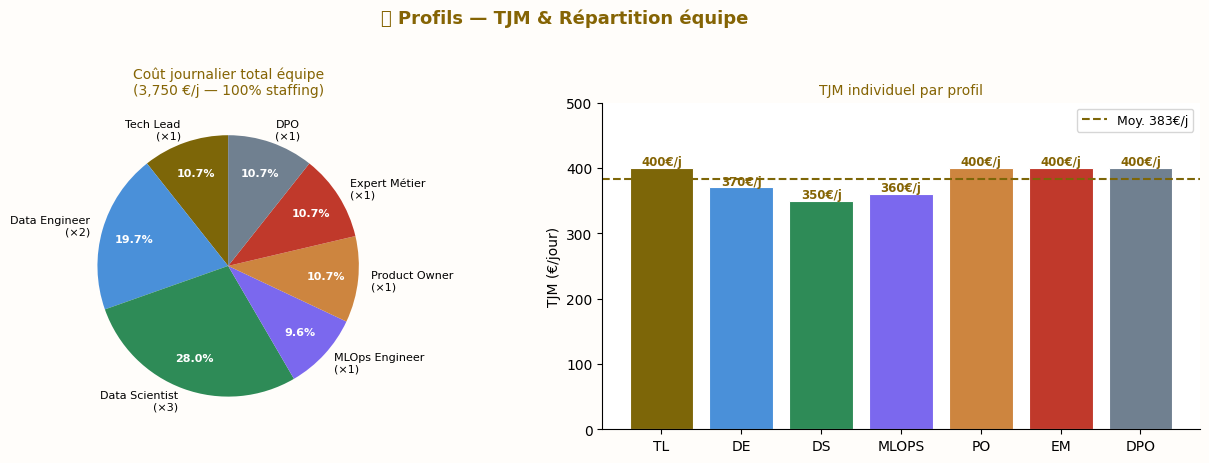

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG_LIGHT)
fig.suptitle('👥 Profils — TJM & Répartition équipe', fontsize=13,
             fontweight='bold', color=GOLD_DARK, y=1.02)

colors = [GOLD, BLUE, GREEN, PURPLE, ORANGE, RED_MUTED, '#708090']
short_labels = [p.nom.split('/')[0].strip() + f'\n(×{p.effectif})'
                for p in repo.load_profils()]

# Camembert TJM équipe
ax1 = axes[0]
vals = df_p['TJM_équipe_€/j'].values
wp, tp, atp = ax1.pie(vals, labels=short_labels, autopct='%1.1f%%',
                       colors=colors, startangle=90, pctdistance=0.75,
                       textprops={'fontsize': 8})
for at in atp:
    at.set_fontsize(8); at.set_fontweight('bold'); at.set_color('white')
ax1.set_title(f'Coût journalier total équipe\n({df_p["TJM_équipe_€/j"].sum():,.0f} €/j — 100% staffing)',
              fontsize=10, color=GOLD_DARK)

# Barres TJM individuel
ax2 = axes[1]
bars = ax2.bar(df_p['Initiales'], df_p['TJM_€/j'], color=colors,
               edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, df_p['TJM_€/j']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'{val}€/j', ha='center', fontsize=8.5, fontweight='bold', color=GOLD_DARK)
ax2.axhline(df_p['TJM_€/j'].mean(), color=GOLD, ls='--', lw=1.5,
            label=f'Moy. {df_p["TJM_€/j"].mean():.0f}€/j')
ax2.set_title('TJM individuel par profil', fontsize=10, color=GOLD_DARK)
ax2.set_ylabel('TJM (€/jour)'); ax2.set_ylim(0, 500)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 📊 Section 2 — Implication croisée : Profil × Phase

In [56]:
from IPython.display import display

df_impl = service.df_implication()
phases  = repo.load_phases()

# Affichage avec pourcentages mis en forme
phase_ids = [ph.id for ph in phases]
pct_df = df_impl.copy()
for pid in phase_ids:
    if pid in pct_df.columns:
        pct_df[pid] = pct_df[pid].apply(lambda x: f"{x*100:.0f}%")

print('📊 Tableau croisé Implication (%) : Profil × Phase')
print('(100% = plein temps | 50% = mi-temps | 20% = implication partielle)')
print('='*70)
display(pct_df)

📊 Tableau croisé Implication (%) : Profil × Phase
(100% = plein temps | 50% = mi-temps | 20% = implication partielle)


,Effectif,TJM_€,P1,P2,P3,P4
Profil,,,,,,
Tech Lead,1,400,50%,50%,100%,20%
Data Engineer,2,370,100%,50%,50%,50%
Data Scientist,3,350,20%,100%,50%,50%
MLOps Engineer,1,360,20%,50%,100%,50%
Product Owner / Chef de Projet,1,400,50%,10%,10%,10%
Expert Métier,1,400,10%,30%,100%,20%
DPO / Référent RGPD,1,400,50%,10%,30%,10%


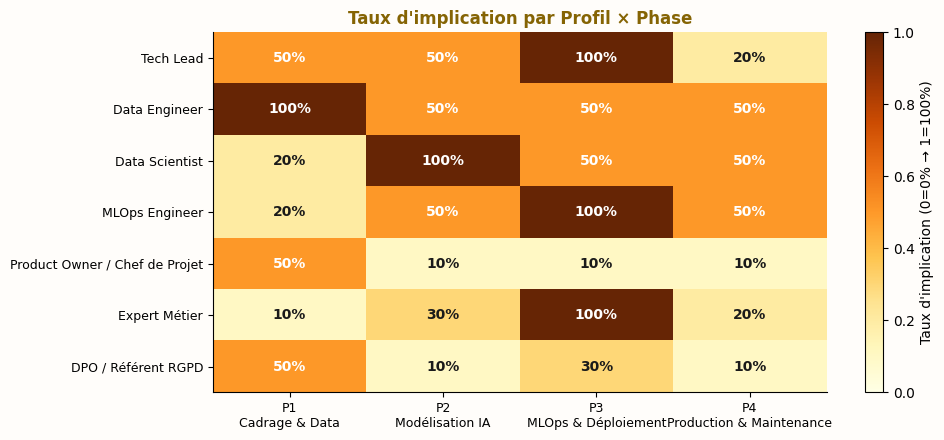

In [57]:
# Heatmap implication
phase_ids = [ph.id for ph in phases]
nums = df_impl[phase_ids].values.astype(float)
phase_noms = [f"{ph.id}\n{ph.nom}" for ph in phases]
profil_noms = df_impl.index.tolist()

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor=BG_LIGHT)
im = ax.imshow(nums, cmap='YlOrBr', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(phase_noms))); ax.set_xticklabels(phase_noms, fontsize=9)
ax.set_yticks(range(len(profil_noms))); ax.set_yticklabels(profil_noms, fontsize=9)
for i in range(len(profil_noms)):
    for j in range(len(phase_ids)):
        v = nums[i, j]
        ax.text(j, i, f"{v*100:.0f}%", ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v >= 0.5 else DARK_TEXT)
ax.set_title('Taux d\'implication par Profil × Phase', fontsize=12,
             fontweight='bold', color=GOLD_DARK)
plt.colorbar(im, ax=ax, label='Taux d\'implication (0=0% → 1=100%)')
plt.tight_layout(); plt.show()

---
## 📊 Section 3 — Coûts RH détaillés par phase

In [61]:
# Obtener el mapeo una sola vez
taches_map = repo.get_taches_mapping()

# Détail par phase
for ph in repo.load_phases():
    if ph.semaines == 0:
        continue
    df_ph = service.compute_cout_phase(ph.id)

    # --- INYECCIÓN DE LA COLUMNA DE TAREAS ---
    # Buscamos la tarea según el perfil y la fase actual
    df_ph['Mission_Phase'] = df_ph['Profil'].apply(
        lambda x: taches_map.get(x, {}).get(ph.id, "Support technique")
    )

    
    print(f'\n{'='*88}')
    print(f'  {ph.id} — {ph.nom}')
    print(f'  📅 {ph.debut} → {ph.fin} ({ph.semaines} sem.) | 🎯 {ph.livrable_cle}')
    print(f'{'='*88}')

    cols = ['Profil','Effectif','TJM_€','Implication_%',
            'H/Sem_Indiv','H/Sem_Équipe','Coût_Sem_€','Coût_Phase_€' , 'Mission_Phase']
    styled = (df_ph[cols].style
              .background_gradient(subset=['Implication_num' if 'Implication_num' in df_ph.columns else 'Coût_Phase_€'],
                                   cmap='Greens', gmap=df_ph['Implication_num'])
              .format({'Coût_Sem_€': '{:,.2f} €', 'Coût_Phase_€': '{:,.2f} €',
                       'H/Sem_Indiv': '{:.1f} h', 'H/Sem_Équipe': '{:.1f} h'})
             )
    display(df_ph[cols].style
            .background_gradient(subset=['Coût_Phase_€'], cmap='Greens')
            .format({'Coût_Sem_€': '{:,.2f} €', 'Coût_Phase_€': '{:,.2f} €',
                     'H/Sem_Indiv': '{:.1f} h', 'H/Sem_Équipe': '{:.1f} h'}))

    cout_heb = df_ph['Coût_Sem_€'].sum()
    cout_tot = df_ph['Coût_Phase_€'].sum()
    print(f"  💰 Coût hebdomadaire : {cout_heb:,.2f} €  |  Budget phase : {cout_tot:,.2f} €")


  P1 — Cadrage & Data
  📅 S1 → S4 (4 sem.) | 🎯 Pipeline données + validation RGPD


,Profil,Effectif,TJM_€,Implication_%,H/Sem_Indiv,H/Sem_Équipe,Coût_Sem_€,Coût_Phase_€,Mission_Phase
0,Tech Lead,1,400,50%,20.0 h,20.0 h,"1,000.00 €","4,000.00 €",Support technique
1,Data Engineer,2,370,100%,40.0 h,80.0 h,"3,700.00 €","14,800.00 €",Support technique
2,Data Scientist,3,350,20%,8.0 h,24.0 h,"1,050.00 €","4,200.00 €","('Analyse exploratoire des données (EDA)', 7)"
3,MLOps Engineer,1,360,20%,8.0 h,8.0 h,360.00 €,"1,440.00 €",Support technique
4,Product Owner / Chef de Projet,1,400,50%,20.0 h,20.0 h,"1,000.00 €","4,000.00 €","('Coordination projet & critères de succès', 0)"
5,Expert Métier,1,400,10%,4.0 h,4.0 h,200.00 €,800.00 €,"('Définition critères de succès métier', 0)"
6,DPO / Référent RGPD,1,400,50%,20.0 h,20.0 h,"1,000.00 €","4,000.00 €","('Validation périmètre données personnelles', 3)"


  💰 Coût hebdomadaire : 8,310.00 €  |  Budget phase : 33,240.00 €

  P2 — Modélisation IA
  📅 S4 → S12 (8 sem.) | 🎯 Modèles IA entraînés + virtual try-on


,Profil,Effectif,TJM_€,Implication_%,H/Sem_Indiv,H/Sem_Équipe,Coût_Sem_€,Coût_Phase_€,Mission_Phase
0,Tech Lead,1,400,50%,20.0 h,20.0 h,"1,000.00 €","8,000.00 €",Support technique
1,Data Engineer,2,370,50%,20.0 h,40.0 h,"1,850.00 €","14,800.00 €",Support technique
2,Data Scientist,3,350,100%,40.0 h,120.0 h,"5,250.00 €","42,000.00 €","('Développement modèles vision + recommandation', 4)"
3,MLOps Engineer,1,360,50%,20.0 h,20.0 h,900.00 €,"7,200.00 €",Support technique
4,Product Owner / Chef de Projet,1,400,10%,4.0 h,4.0 h,200.00 €,"1,600.00 €","('Suivi avancement modélisation', 0)"
5,Expert Métier,1,400,30%,12.0 h,12.0 h,600.00 €,"4,800.00 €","('Validation qualité des recommandations style', 4)"
6,DPO / Référent RGPD,1,400,10%,4.0 h,4.0 h,200.00 €,"1,600.00 €","('Audit conformité algorithmique', 3)"


  💰 Coût hebdomadaire : 10,000.00 €  |  Budget phase : 80,000.00 €

  P3 — MLOps & Déploiement
  📅 S12 → S18 (6 sem.) | 🎯 Endpoints Azure ML déployés (prod)


,Profil,Effectif,TJM_€,Implication_%,H/Sem_Indiv,H/Sem_Équipe,Coût_Sem_€,Coût_Phase_€,Mission_Phase
0,Tech Lead,1,400,100%,40.0 h,40.0 h,"2,000.00 €","12,000.00 €",Support technique
1,Data Engineer,2,370,50%,20.0 h,40.0 h,"1,850.00 €","11,100.00 €",Support technique
2,Data Scientist,3,350,50%,20.0 h,60.0 h,"2,625.00 €","15,750.00 €","('Fine-tuning GPT-4V & optimisation endpoints', 5)"
3,MLOps Engineer,1,360,100%,40.0 h,40.0 h,"1,800.00 €","10,800.00 €",Support technique
4,Product Owner / Chef de Projet,1,400,10%,4.0 h,4.0 h,200.00 €,"1,200.00 €","('Préparation présentation COMEX', 0)"
5,Expert Métier,1,400,100%,40.0 h,40.0 h,"2,000.00 €","12,000.00 €","('Tests d’acceptation finale (UAT) application', 1)"
6,DPO / Référent RGPD,1,400,30%,12.0 h,12.0 h,600.00 €,"3,600.00 €","('Validation conformité finale Ready-to-Deploy', 3)"


  💰 Coût hebdomadaire : 11,075.00 €  |  Budget phase : 66,450.00 €


### Coûts RH résumes par phase (1)

In [62]:
# 1. CONSOLIDACIÓN DE DATOS
# Creamos el DataFrame base con los perfiles
df_master = df_p[['Profil', 'Effectif', 'TJM_€/j']].copy()

# Iteramos por las fases para añadir columnas horizontalmente
for ph in repo.load_phases():
    if ph.semaines == 0:
        continue
    
    # Obtenemos los datos de esta fase específica
    df_ph = service.compute_cout_phase(ph.id)
    
    # Añadimos columnas de Implicación y Total al maestro
    # Usamos merge para asegurar que los perfiles coincidan correctamente
    df_master[f'{ph.id}_%'] = df_ph['Implication_%']
    df_master[f'{ph.id}_Total'] = df_ph['Coût_Phase_€']

# 2. CÁLCULO DE TOTALES
# Suma horizontal por perfil
cols_totales_fases = [c for c in df_master.columns if 'Total' in c]
df_master['TOTAL_PROYECTO'] = df_master[cols_totales_fases].sum(axis=1)

# Fila de TOTAL EQUIPE (Suma vertical)
df_final = df_master.copy()
totales_verticales = df_final.sum(numeric_only=True)
df_final.loc['TOTAL'] = totales_verticales
df_final.loc['TOTAL', 'Profil'] = 'TOTAL EQUIPE'

# Limpiar valores que no tienen sentido sumar verticalmente (TJM, Effectif, %)
cols_limpiar = ['TJM_€/j', 'Effectif'] + [c for c in df_final.columns if '%' in c]
df_final.loc['TOTAL', cols_limpiar] = np.nan

# 3. ESTILO VISUAL (Colores por bloques como en la imagen)
print(f"📊 MATRICE BUDGÉTAIRE RÉCAPITULATIVE (Total par Phase)")
print("="*125)

# Formateo de moneda y porcentajes
formatos = {c: "{:,.0f} €" for c in df_final.columns if 'Total' in c or 'TOTAL' in c}
formatos['TJM_€/j'] = "{:,.0f} €"
formatos['Effectif'] = "{:.0f}"

styled = df_final.style.format(formatos, na_rep="")

# Aplicar colores de fondo por bloques de fase (Azul y Amarillo alternados)
colores_fases = ['#d9e9ff', '#fff2cc', '#d9e9ff', '#fff2cc'] # Azul, Amarillo, Azul...
fases_id = [ph.id for ph in repo.load_phases() if ph.semaines > 0]

for i, f_id in enumerate(fases_id):
    cols_fase = [f'{f_id}_%', f'{f_id}_Total']
    styled = styled.set_properties(**{'background-color': colores_fases[i]}, subset=cols_fase)

# Resaltar la columna TOTAL PROYECTO y la fila TOTAL
styled = styled.set_properties(**{'font-weight': 'bold', 'background-color': '#f0f0f0'}, subset=['TOTAL_PROYECTO'])
styled = styled.set_properties(subset=pd.IndexSlice['TOTAL', :], **{'background-color': '#cccccc', 'font-weight': 'bold'})

display(styled)

📊 MATRICE BUDGÉTAIRE RÉCAPITULATIVE (Total par Phase)


,Profil,Effectif,TJM_€/j,P1_%,P1_Total,P2_%,P2_Total,P3_%,P3_Total,TOTAL_PROYECTO
0,Tech Lead,1,400 €,50%,"4,000 €",50%,"8,000 €",100%,"12,000 €","24,000 €"
1,Data Engineer,2,370 €,100%,"14,800 €",50%,"14,800 €",50%,"11,100 €","40,700 €"
2,Data Scientist,3,350 €,20%,"4,200 €",100%,"42,000 €",50%,"15,750 €","61,950 €"
3,MLOps Engineer,1,360 €,20%,"1,440 €",50%,"7,200 €",100%,"10,800 €","19,440 €"
4,Product Owner / Chef de Projet,1,400 €,50%,"4,000 €",10%,"1,600 €",10%,"1,200 €","6,800 €"
5,Expert Métier,1,400 €,10%,800 €,30%,"4,800 €",100%,"12,000 €","17,600 €"
6,DPO / Référent RGPD,1,400 €,50%,"4,000 €",10%,"1,600 €",30%,"3,600 €","9,200 €"
TOTAL,TOTAL EQUIPE,,,,"33,240 €",,"80,000 €",,"66,450 €","179,690 €"


### Coûts RH résumes par phase (2) Synthèse toutes phases


💰 Coûts RH par Phase


,Phase,Nom,Semaines,Jours_ouvrés,JH_Total,Coût_RH_€,Livrable
0,P1,Cadrage & Data,4,20,88.000000,"33,240 €",Pipeline données + validation RGPD
1,P2,Modélisation IA,8,40,220.000000,"80,000 €",Modèles IA entraînés + virtual try-on
2,P3,MLOps & Déploiement,6,30,177.000000,"66,450 €",Endpoints Azure ML déployés (prod)



  TOTAL développement (one-shot) : 179,690 €


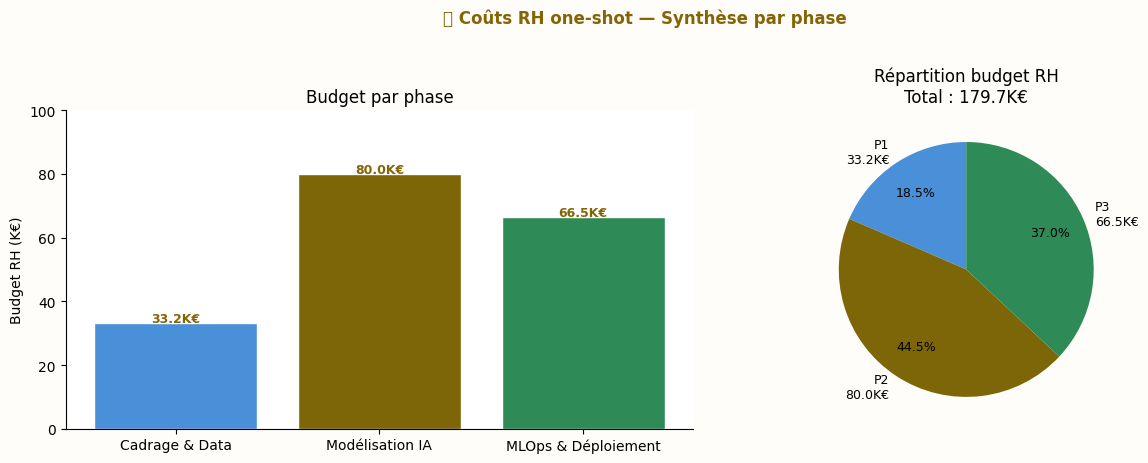

In [63]:
# Synthèse toutes phases
df_all = service.df_cout_all_phases()
renderer.render_cout_phases(df_all)

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG_LIGHT)
fig.suptitle('💰 Coûts RH one-shot — Synthèse par phase',
             fontsize=12, fontweight='bold', color=GOLD_DARK, y=1.02)

bars = axes[0].bar(df_all['Nom'], df_all['Coût_RH_€']/1000,
                    color=PHASE_COLORS[:len(df_all)], edgecolor='white')
for bar, v in zip(bars, df_all['Coût_RH_€']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v/1000:.1f}K€', ha='center', fontweight='bold', fontsize=9, color=GOLD_DARK)
axes[0].set_ylabel('Budget RH (K€)'); axes[0].set_title('Budget par phase')
axes[0].set_ylim(0, df_all['Coût_RH_€'].max()/1000*1.25)

axes[1].pie(df_all['Coût_RH_€'],
            labels=[f"{r['Phase']}\n{r['Coût_RH_€']/1000:.1f}K€" for _,r in df_all.iterrows()],
            autopct='%1.1f%%', colors=PHASE_COLORS[:len(df_all)],
            startangle=90, pctdistance=0.72, textprops={'fontsize': 9})
axes[1].set_title(f'Répartition budget RH\nTotal : {df_all["Coût_RH_€"].sum()/1000:.1f}K€')
plt.tight_layout(); plt.show()

### Coûts RH résumes par phase (3) Composition 

#### 1. Funtion Composition 

In [64]:
def get_dynamic_composition(phase_id, repo, service):
    """Genera el texto 'Perfil x %' basado en los datos reales del repo."""
    df_ph = service.compute_cout_phase(phase_id)
    comp = []
    
    for _, row in df_ph.iterrows():
        pct = row['Implication_%']
        # Solo incluimos perfiles con implicación > 0%
        if float(pct.strip('%')) > 0:
            nombre = row['Profil']
            efecto = row['Effectif']
            prefix = f"{int(efecto)} " if efecto > 1 else ""
            comp.append(f"{prefix}{nombre}×{pct}")
    
    semaines = next(ph.semaines for ph in repo.load_phases() if ph.id == phase_id)
    return " + ".join(comp) + f" × {semaines} sem."

#### 2. Add Azure Setup (one-shot)

In [65]:
import pandas as pd


# 1. Obtener datos base del servicio
df_all = service.df_cout_all_phases()

# 2. PROCESAMIENTO DE DATOS
resumen_rows = []
lista_jh_fases = [] # Para guardar los totales numéricos y sumarlos al final

for _, row in df_all.iterrows():
    p_id = row['Phase']
    
    # Calculamos los JH reales de esta fase sumando (Efectivo * Implicación * Días_Fase)
    df_detalle = service.compute_cout_phase(p_id)
    # Convertimos '50%' a 0.5 para el cálculo
    jh_fase = (
        df_detalle['Effectif'] * 
        (df_detalle['Implication_%'].str.rstrip('%').astype(float) / 100) * 
        row['Jours_ouvrés']
    ).sum()
    
    lista_jh_fases.append(jh_fase)

    resumen_rows.append({
        'Phase': f"Phase {p_id.replace('P','')}",
        'Compositionn': get_dynamic_composition(p_id, repo, service),
        'Duraction': f"{row['Semaines']} sem." if p_id != 'P4' else "En continu",
        'Charge Total (JH)': f"{int(round(jh_fase))} j",
        'Devis': row['Coût_RH_€']
    })
    
# 3. Añadir Azure Setup (como antes)
resumen_rows.append({
    'Phase': 'Azure Setup (one-shot)',
    'Compositionn': 'Configuration initiale Azure AD B2C, Key Vault, Purview, ML Studio',
    'Duraction': '—',
    'Charge Total (JH)': '—',
    'Devis': 5000
})

df_resumen = pd.DataFrame(resumen_rows)

# 4. Cálculo de la fila TOTAL (CORREGIDO)
total_semaines = df_all['Semaines'].sum()
total_jh_num   = sum(lista_jh_fases) # Suma de los JH calculados arriba
total_devis    = df_resumen['Devis'].sum()

fila_total = pd.DataFrame([{
    'Phase': 'TOTAL PROJET',
    'Compositionn': '',
    'Duraction': f"{total_semaines} sem.",
    'Charge Total (JH)': f"{int(round(total_jh_num))} j", # <--- Ahora mostrará ~472 j o similar
    'Devis': total_devis
}])

df_final = pd.concat([df_resumen, fila_total], ignore_index=True)

#### 3. Create Table

In [66]:
print("📌 RESUMEN EJECUTIVO DE INVERSIÓN (Final)")
print("-" * 115)

# Aplicar estilos
styled = df_final.style.format({
    'Devis': lambda x: f"~{x:,.0f} €"
}).set_properties(**{
    'text-align': 'left',
    'background-color': '#fffdf5',
    'border-bottom': '1px solid #e6e6e6',
    'padding': '15px'
})

# Resaltar Devis (Precio)
styled = styled.set_properties(subset=['Devis'], **{
    'font-weight': 'bold',
    'color': '#856404',
    'font-size': '1.15em',
    'text-align': 'right'
})

# Estilo para Compositionn (Gris e Itálica)
styled = styled.set_properties(subset=['Compositionn'], **{
    'color': '#7f8c8d',
    'font-style': 'italic',
    'font-size': '0.85em'
})

# Resaltar la fila de TOTAL
styled = styled.set_properties(
    subset=pd.IndexSlice[df_final.index[-1], :], 
    **{
        'background-color': '#fdfaf0',
        'border-top': '2.5px solid #856404',
        'font-weight': 'bold',
        'font-size': '1.1em'
    }
).hide(axis='index')

display(styled)

📌 RESUMEN EJECUTIVO DE INVERSIÓN (Final)
-------------------------------------------------------------------------------------------------------------------


Phase,Compositionn,Duraction,Charge Total (JH),Devis
Phase 1,Tech Lead×50% + 2 Data Engineer×100% + 3 Data Scientist×20% + MLOps Engineer×20% + Product Owner / Chef de Projet×50% + Expert Métier×10% + DPO / Référent RGPD×50% × 4 sem.,4 sem.,88 j,"~33,240 €"
Phase 2,Tech Lead×50% + 2 Data Engineer×50% + 3 Data Scientist×100% + MLOps Engineer×50% + Product Owner / Chef de Projet×10% + Expert Métier×30% + DPO / Référent RGPD×10% × 8 sem.,8 sem.,220 j,"~80,000 €"
Phase 3,Tech Lead×100% + 2 Data Engineer×50% + 3 Data Scientist×50% + MLOps Engineer×100% + Product Owner / Chef de Projet×10% + Expert Métier×100% + DPO / Référent RGPD×30% × 6 sem.,6 sem.,177 j,"~66,450 €"
Azure Setup (one-shot),"Configuration initiale Azure AD B2C, Key Vault, Purview, ML Studio",—,—,"~5,000 €"
TOTAL PROJET,,18 sem.,485 j,"~184,690 €"


---
## 📊 Section 4 — Matrice RACI


🗂️  Matrice RACI — Profils × Briques
Légende : 🔨=Développement  🔧=Maintenance  ✅=Validation  👁=Supervision


,Auth & Gateway,Sécurité & RGPD,Briques IA (CV+Reco),Virtual Try-On (GPT-4V),MLOps Pipeline,Stockage & Data,Observabilité & ROI
Tech Lead,🔨✅,✅,✅,✅,✅,✅,✅
Data Engineer,🔨,🔨,🔧,🔧,🔧,🔨,🔧
Data Scientist,👁,👁,🔨,🔨,🔧,🔧,🔧
MLOps Engineer,🔧,🔧,🔧,🔧,🔨,🔧,🔨
Product Owner / Chef de Projet,✅,✅,✅,✅,✅,✅,✅
Expert Métier,👁,👁,✅,✅,👁,👁,✅
DPO / Référent RGPD,👁,🔨✅,👁,👁,👁,✅,👁


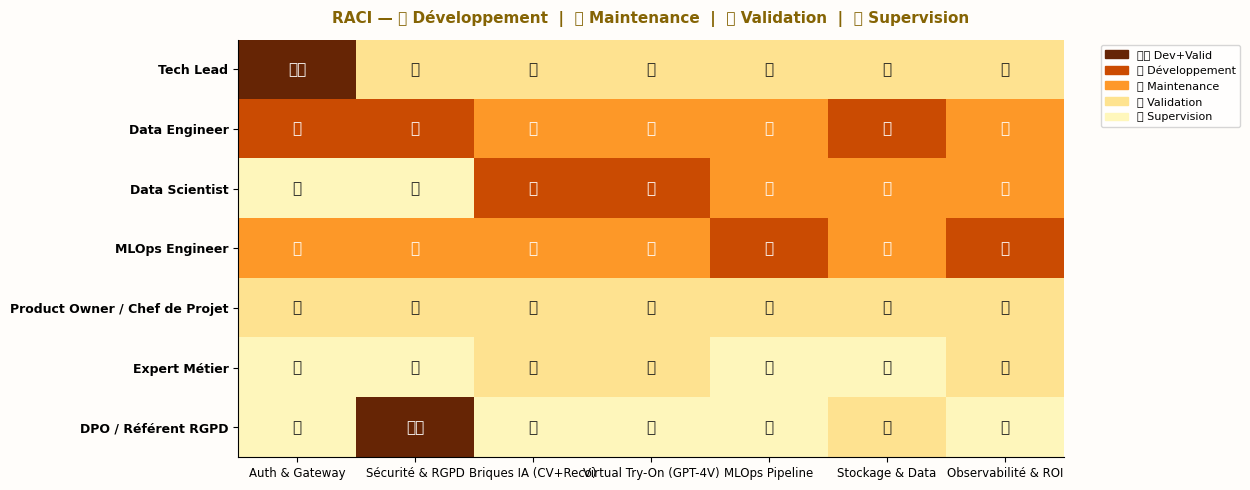

In [67]:
df_raci, raci_vals = service.df_raci()
renderer.render_raci(df_raci)

# Heatmap RACI
fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG_LIGHT)
ax.imshow(raci_vals, cmap='YlOrBr', aspect='auto', vmin=0, vmax=4)
ax.set_xticks(range(raci_vals.shape[1]))
ax.set_xticklabels(df_raci.columns.tolist(), fontsize=8.5)
ax.set_yticks(range(raci_vals.shape[0]))
ax.set_yticklabels(df_raci.index.tolist(), fontsize=9, fontweight='bold')
raci_labels = df_raci.values.tolist()
for i in range(raci_vals.shape[0]):
    for j in range(raci_vals.shape[1]):
        v = raci_vals[i, j]
        ax.text(j, i, raci_labels[i][j], ha='center', va='center',
                fontsize=11, color='white' if v >= 2 else DARK_TEXT)
ax.set_title('RACI — 🔨 Développement  |  🔧 Maintenance  |  ✅ Validation  |  👁 Supervision',
             fontsize=11, fontweight='bold', color=GOLD_DARK, pad=12)
legend_el = [mpatches.Patch(color=plt.cm.YlOrBr(v/4), label=lbl)
             for v, lbl in [(4,'🔨✅ Dev+Valid'),(3,'🔨 Développement'),
                            (2,'🔧 Maintenance'),(1,'✅ Validation'),(0.5,'👁 Supervision')]]
ax.legend(handles=legend_el, loc='upper right', bbox_to_anchor=(1.22, 1), fontsize=8)
plt.tight_layout(); plt.show()

---
## 📊 Section 5 — Coûts récurrents mensuels (Production)


🔄 Coûts Récurrents Mensuels (Production)


,Catégorie,Service,Best_Case_€/mois,Worst_Case_€/mois,Moy_€/mois
0,💻 Compute,Azure ML Endpoints (inférence),800 €,"1,500 €","1,150 €"
1,💻 Compute,Azure API Management,200 €,400 €,300 €
2,💾 Storage,Azure Blob Storage (photos),150 €,400 €,275 €
3,💾 Storage,Cosmos DB + Data Lake Gen2,250 €,500 €,375 €
4,🤖 IA/API,Azure OpenAI GPT-4V (try-on),600 €,"2,000 €","1,300 €"
5,🛡️ Sécurité,Key Vault + Purview + Monitor,150 €,300 €,225 €
6,👥 RH,Maintenance équipe (partielle),"7,200 €","10,000 €","8,600 €"



  Best  Case mensuel : 9,350 €/mois
  Worst Case mensuel : 15,100 €/mois
  Mean  Case mensuel : 12,225 €/mois


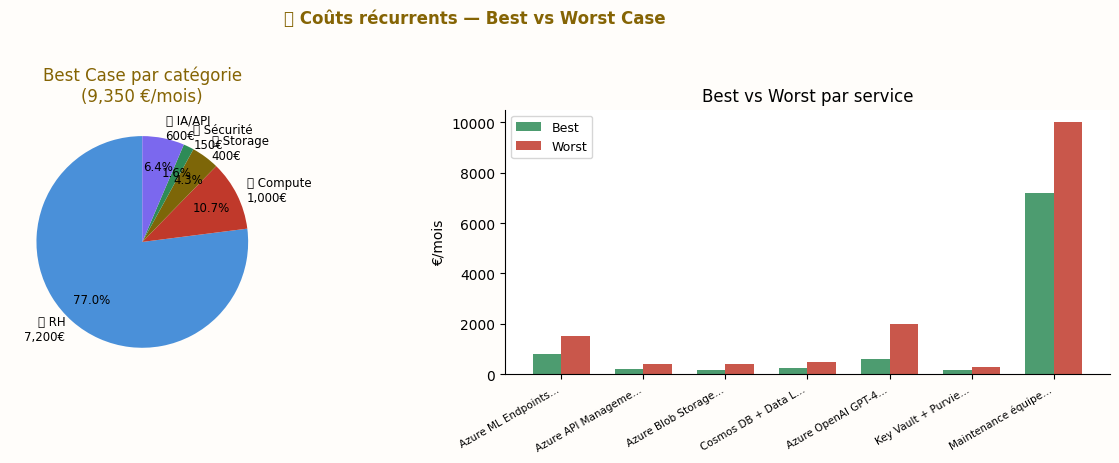

In [68]:
df_rec = service.df_recurrents()
renderer.render_recurrents(df_rec)

df_rec['Moyenne_€/mois'] = (df_rec['Best_Case_€/mois'] + df_rec['Worst_Case_€/mois']) / 2

# Calcular la columna 'Moyenne' por servicio

# Totales globales
total_best = df_rec['Best_Case_€/mois'].sum()
total_worst = df_rec['Worst_Case_€/mois'].sum()
total_moyenne = df_rec['Moyenne_€/mois'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG_LIGHT)
fig.suptitle('🔄 Coûts récurrents — Best vs Worst Case',
             fontsize=12, fontweight='bold', color=GOLD_DARK, y=1.02)

cats = df_rec.groupby('Catégorie')['Best_Case_€/mois'].sum()
cat_colors = [BLUE, RED_MUTED, GOLD, GREEN, PURPLE]
axes[0].pie(cats.values,
            labels=[f"{k}\n{v:,.0f}€" for k,v in cats.items()],
            autopct='%1.1f%%', colors=cat_colors[:len(cats)],
            startangle=90, pctdistance=0.73, textprops={'fontsize': 8.5})
axes[0].set_title(f'Best Case par catégorie\n({df_rec["Best_Case_€/mois"].sum():,.0f} €/mois)',
                  color=GOLD_DARK)

services_sh = [s[:18]+'…' if len(s)>18 else s for s in df_rec['Service']]
x = np.arange(len(services_sh)); w = 0.35
axes[1].bar(x-w/2, df_rec['Best_Case_€/mois'] , w, label='Best', color=GREEN, alpha=0.85)
axes[1].bar(x+w/2, df_rec['Worst_Case_€/mois'], w, label='Worst', color=RED_MUTED, alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(services_sh, rotation=30, ha='right', fontsize=7.5)
axes[1].set_ylabel('€/mois'); axes[1].set_title('Best vs Worst par service')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 📊 Section 6 — ROI & Projection de rentabilité

#### 1. Calcul Gains marketing

In [69]:
# Gains marketing
df_gm = service.df_gains()
print('📈 Gains Marketing — Source : Étude marketing Fashion Insta')
print('='*60)
display(df_gm.style.format({'CA_Base_€': '{:,.0f} €', 'Gain_annuel_€': '{:,.0f} €'}))

📈 Gains Marketing — Source : Étude marketing Fashion Insta


,Canal,CA_Base_€,Taux_%,Gain_annuel_€
0,CA Web (+14%),"5,200,000 €",14%,"728,000 €"
1,CA Magasin (+4%),"5,200,000 €",4%,"208,000 €"
2,🎯 TOTAL,"10,400,000 €",—,"936,000 €"


#### 2. Projection ROI — Jalons clés

In [70]:
df_roi, be = service.compute_roi_projection(mois_max=42)
renderer.render_roi(df_roi, be)

 gain_annuel: 936,000 
 gain_mensuel: 78,000 
 gain_mensuel_web: 60,667 
 gain_mensuel_magasin: 17,333 
 oneshot: 184,690 
 rec_mois: 9,350 
 0 | D:      0.0/     0.0 -> T.Dev:       0.0   R:      0.0/     0.0 -> T.Rec:       0.0     TOTAL:        0.0   G.WEB:       0€ |  G.MAG:       0€ |  GAIN:       0€   NET:        0€
 1 | D:  41042.2/     0.0 -> T.Dev:   41042.2   R:    935.0/     0.0 -> T.Rec:     935.0     TOTAL:    41977.2   G.WEB:       0€ |  G.MAG:       0€ |  GAIN:       0€   NET:   -41977€
 2 | D:  82084.4/     0.0 -> T.Dev:   82084.4   R:   1870.0/     0.0 -> T.Rec:    1870.0     TOTAL:    83954.4   G.WEB:       0€ |  G.MAG:       0€ |  GAIN:       0€   NET:   -83954€
 3 | D: 123126.7/     0.0 -> T.Dev:  123126.7   R:   2805.0/     0.0 -> T.Rec:    2805.0     TOTAL:   125931.7   G.WEB:       0€ |  G.MAG:       0€ |  GAIN:       0€   NET:  -125932€
 4 | D: 164168.9/     0.0 -> T.Dev:  164168.9   R:   3740.0/     0.0 -> T.Rec:    3740.0     TOTAL:   167908.9   G.WEB:       0

,Mois,Coût_Dev_€,Coût_Récurrent_€,Coûts_cumulés_€,Gains_Web_€,Gains_Magasin_€,Gains_cumulés_€,Résultat_net_€
0,0,0,0,0 €,0,0,0 €,+0 €
6,6,184690,18232,"202,922 €",45500,13000,"58,500 €","-144,422 €"
12,12,184690,74332,"259,022 €",227500,65000,"292,500 €","+33,478 €"
18,18,184690,130432,"315,122 €",455000,130000,"585,000 €","+269,878 €"
24,24,184690,186532,"371,222 €",819000,234000,"1,053,000 €","+681,778 €"
30,30,184690,242632,"427,322 €",1183000,338000,"1,521,000 €","+1,093,678 €"
36,36,184690,298732,"483,422 €",1547000,442000,"1,989,000 €","+1,505,578 €"
42,42,184690,354832,"539,522 €",1911000,546000,"2,457,000 €","+1,917,478 €"



  ⭐ Break-even estimé : Mois 11


#### 3. Graphiques: PROJECTION ROI & RENTABILITÉ, RÉSULTAT NET CUMULÉ (CASH-FLOW)

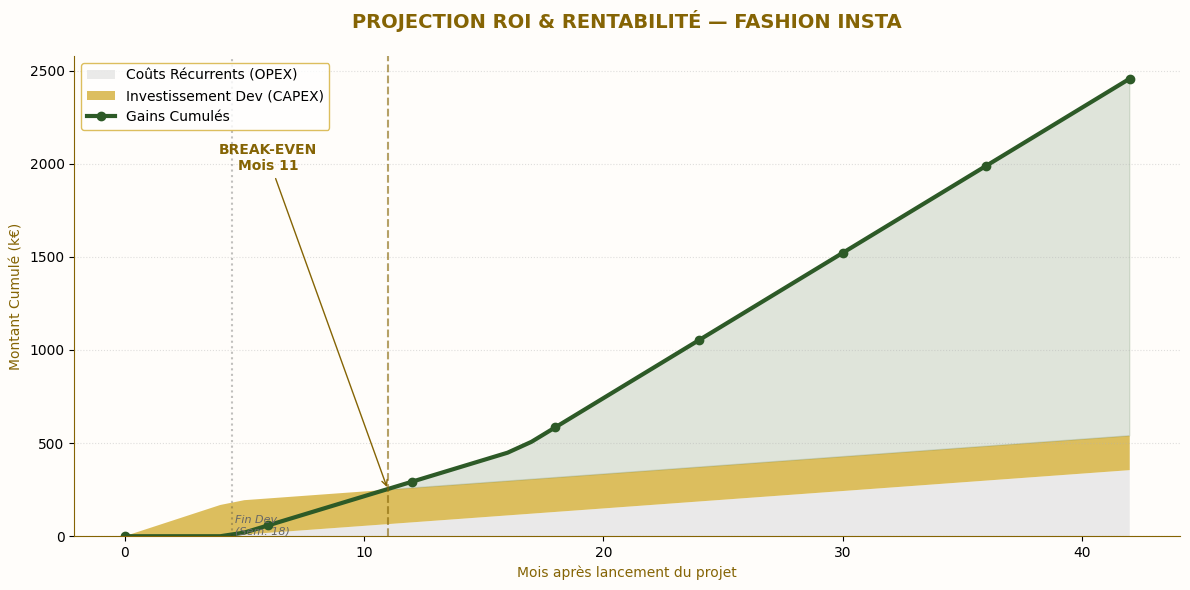

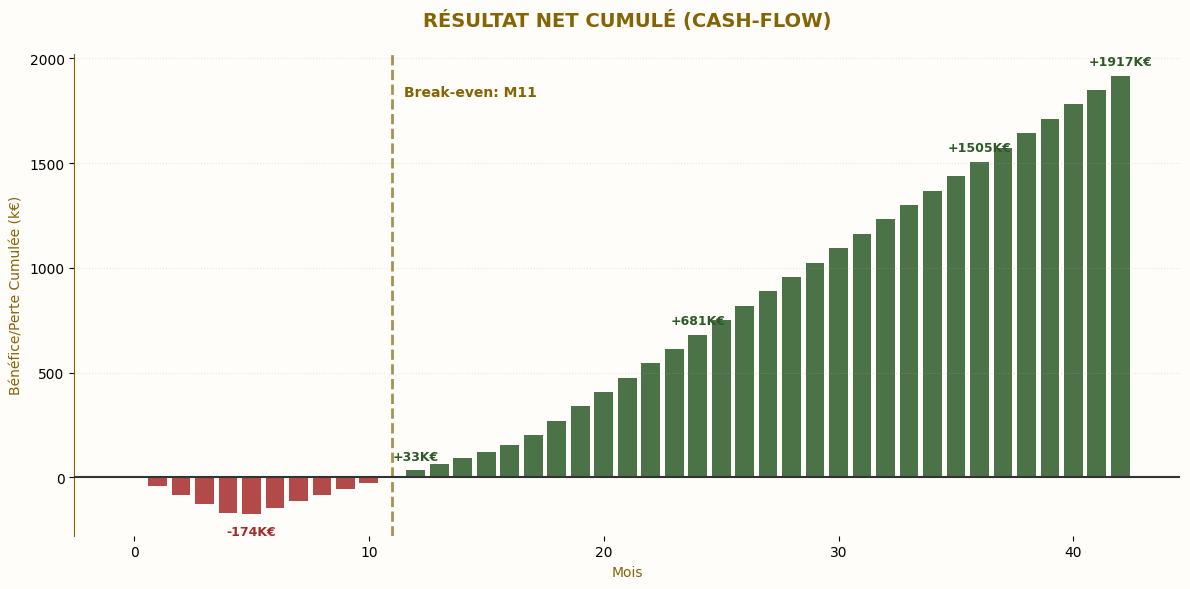

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta Fashion Insta
GOLD_DARK   = '#856404'   # El dorado del logo
GOLD_LIGHT  = '#D4AF37'
BG_LIGHT    = '#FFFDFA'   # Fondo crema suave
GREEN_SUST  = '#2D5A27'   # Verde para ganancias (elegante)
RED_COST    = '#A52A2A'   # Ocre/Rojizo para deuda

def render_elegant_roi(df_roi, break_even_mois):
    plt.rcParams['font.family'] = 'sans-serif'
    fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_LIGHT)
    ax.set_facecolor(BG_LIGHT)

    mois = df_roi['Mois']
    
    # 1. ÁREAS APILADAS PARA COSTES (Visualiza CAPEX vs OPEX)
    ax.stackplot(mois, 
                 df_roi['Coût_Récurrent_€'] / 1000, 
                 df_roi['Coût_Dev_€'] / 1000, 
                 labels=['Coûts Récurrents (OPEX)', 'Investissement Dev (CAPEX)'],
                 colors=['#E5E5E5', GOLD_LIGHT], alpha=0.8)

    # 2. LÍNEA DE GANANCIAS (Gains)
    ax.plot(mois, df_roi['Gains_cumulés_€'] / 1000, 
            color=GREEN_SUST, linewidth=3, label='Gains Cumulés', marker='o', markevery=6)

    # 3. LÍNEA DE RESULTADO NETO (La sombra del éxito)
    ax.fill_between(mois, df_roi['Coûts_cumulés_€'] / 1000, df_roi['Gains_cumulés_€'] / 1000, 
                    where=(df_roi['Gains_cumulés_€'] >= df_roi['Coûts_cumulés_€']),
                    color=GREEN_SUST, alpha=0.15, interpolate=True)

    # Marcador de Break-even
    if break_even_mois:
        ax.axvline(x=break_even_mois, color=GOLD_DARK, linestyle='--', alpha=0.6)
        ax.annotate(f'BREAK-EVEN\nMois {break_even_mois}', 
                    xy=(break_even_mois, df_roi.loc[break_even_mois, 'Coûts_cumulés_€']/1000),
                    xytext=(break_even_mois-5, (df_roi['Gains_cumulés_€'].max()/1000)*0.8),
                    arrowprops=dict(arrowstyle='->', color=GOLD_DARK),
                    fontsize=10, fontweight='bold', color=GOLD_DARK, ha='center')

    # Marcador Fin de Desarrollo (Semana 18)
    ax.axvline(x=4.5, color='#333333', linestyle=':', alpha=0.3)
    ax.text(4.6, 10, 'Fin Dev\n(Sem. 18)', fontsize=8, color='#666666', fontstyle='italic')

    # Estética de ejes
    ax.set_title('PROJECTION ROI & RENTABILITÉ — FASHION INSTA', 
                 fontsize=14, fontweight='bold', pad=20, color=GOLD_DARK)
    ax.set_xlabel('Mois après lancement du projet', fontsize=10, color=GOLD_DARK)
    ax.set_ylabel('Montant Cumulé (k€)', fontsize=10, color=GOLD_DARK)
    
    # Grid y bordes
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color(GOLD_DARK)
    ax.spines['left'].set_color(GOLD_DARK)

    ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor=GOLD_LIGHT)
    
    plt.tight_layout()
    plt.show()

# Ejecución
render_elegant_roi(df_roi, be)

def render_elegant_net_result(df_roi, break_even_mois):
    plt.rcParams['font.family'] = 'sans-serif'
    fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_LIGHT)
    ax.set_facecolor(BG_LIGHT)

    mois = df_roi['Mois']
    neto = df_roi['Résultat_net_€'] / 1000  # Convertir a k€

    # Colores condicionales: Ocre para negativo, Verde Esmeralda para positivo
    colors = [RED_COST if val < 0 else GREEN_SUST for val in neto]
    
    # Renderizado de barras
    bars = ax.bar(mois, neto, color=colors, alpha=0.85, width=0.8, edgecolor='none')

    # Línea de equilibrio (Hormigón/Negro suave)
    ax.axhline(0, color='#333333', linewidth=1.5, zorder=3)

    # Resaltar hitos específicos con etiquetas de texto (k€)
    # Ejemplo: M5 (valle), M12, M24, M36, M42
    hitos = [5, 12, 24, 36, 42]
    for i in hitos:
        if i < len(neto):
            val = neto[i]
            prefix = "+" if val > 0 else ""
            ax.text(i, val + (50 if val > 0 else -100), f"{prefix}{int(val)}K€", 
                    ha='center', fontsize=9, fontweight='bold', color=colors[i])

    # Marcador de Break-even (Vertical Dorada)
    if break_even_mois:
        ax.axvline(x=break_even_mois, color=GOLD_DARK, linestyle='--', linewidth=2, alpha=0.7)
        ax.text(break_even_mois + 0.5, ax.get_ylim()[1]*0.9, f'Break-even: M{break_even_mois}', 
                color=GOLD_DARK, fontweight='bold', fontsize=10)

    # Estética y Títulos
    ax.set_title('RÉSULTAT NET CUMULÉ (CASH-FLOW)', fontsize=14, fontweight='bold', pad=20, color=GOLD_DARK)
    ax.set_xlabel('Mois', fontsize=10, color=GOLD_DARK)
    ax.set_ylabel('Bénéfice/Perte Cumulée (k€)', fontsize=10, color=GOLD_DARK)

    # Limpieza visual
    ax.grid(True, axis='y', linestyle=':', alpha=0.3)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_color(GOLD_DARK)

    plt.tight_layout()
    plt.show()

# Ejecución
render_elegant_net_result(df_roi, be)

---
## 📋 Section 7 — Synthèse exécutive COMEX

In [72]:
df_all  = service.df_cout_all_phases()
df_rec  = service.df_recurrents()
df_gm   = service.df_gains()
# df_roi, be = service.compute_roi_projection()

gain_total = sum(g.gain_annuel for g in repo.load_gains_marketing())
cout_oneshot = df_all['Coût_RH_€'].sum()
rec_bc = df_rec['Best_Case_€/mois'].sum()
rec_wc = df_rec['Worst_Case_€/mois'].sum()
net_an3 = df_roi.loc[df_roi['Mois']==42, 'Résultat_net_€'].values[0]

print('='*65)
print('   🏷️  FASHION INSTA — Synthèse Exécutive Cadrage IA')
print('='*65)
print('\n📦 ÉQUIPE DATA & IA')
for p in repo.load_profils():
    print(f"   · {p.nom:<32} ×{p.effectif}  {p.tjm_eur}€/j")

print('\n🗓️  TIMELINE')
for ph in repo.load_phases():
    dur = f'{ph.semaines} sem.' if ph.semaines else 'ongoing'
    print(f"   · {ph.id} — {ph.nom:<28} {ph.debut} → {ph.fin} ({dur})")

print('\n💰 COÛTS')
for _, r in df_all.iterrows():
    print(f"   · {r['Phase']} {r['Nom']:<28}: {r['Coût_RH_€']:>10,.0f} €")
print(f"   {'TOTAL one-shot':<36}: {cout_oneshot:>10,.0f} €")
print(f"   Récurrents Best Case mensuel    : {rec_bc:>10,.0f} €/mois")
print(f"   Récurrents Worst Case mensuel   : {rec_wc:>10,.0f} €/mois")

print('\n📈 ROI')
for g in repo.load_gains_marketing():
    print(f"   · {g.canal:<28}: {g.gain_annuel:>10,.0f} €/an")
print(f"   GAIN TOTAL ANNUEL                : {gain_total:>10,.0f} €/an")
print(f"   Break-even                       :      Mois {be}")
print(f"   Résultat net An 3                : {net_an3:>+10,.0f} €")
if cout_oneshot > 0:
    print(f"   ROI sur 3 ans                    :      {net_an3/cout_oneshot*100:.0f}%")
print('='*65)

   🏷️  FASHION INSTA — Synthèse Exécutive Cadrage IA

📦 ÉQUIPE DATA & IA
   · Tech Lead                        ×1  400€/j
   · Data Engineer                    ×2  370€/j
   · Data Scientist                   ×3  350€/j
   · MLOps Engineer                   ×1  360€/j
   · Product Owner / Chef de Projet   ×1  400€/j
   · Expert Métier                    ×1  400€/j
   · DPO / Référent RGPD              ×1  400€/j

🗓️  TIMELINE
   · P1 — Cadrage & Data               S1 → S4 (4 sem.)
   · P2 — Modélisation IA              S4 → S12 (8 sem.)
   · P3 — MLOps & Déploiement          S12 → S18 (6 sem.)
   · P4 — Production & Maintenance     M6+ → ongoing (ongoing)

💰 COÛTS
   · P1 Cadrage & Data              :     33,240 €
   · P2 Modélisation IA             :     80,000 €
   · P3 MLOps & Déploiement         :     66,450 €
   TOTAL one-shot                      :    179,690 €
   Récurrents Best Case mensuel    :      9,350 €/mois
   Récurrents Worst Case mensuel   :     15,100 €/mois

📈 ROI
   